# Day 20 — Project-Specific Robustness / Ablation Study

## Objective

This study evaluates how White Balance + CLAHE image enhancement affects YOLOv8n object detection across the three supplied underwater datasets.

The analysis compares:

- Raw Image + YOLOv8n
- WB+CLAHE Enhanced Image + YOLOv8n

The comparison focuses on Precision, Recall, mAP@0.5, mAP@0.5:0.95 and inference speed.

The study also analyses class-level error propagation and interprets the results with respect to the project research question.

In [ ]:
from google.colab import drive
drive.mount("/content/drive",force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Day 20 - Project-Specific Robustness / Ablation Study")
print("Environment ready.")

Day 20 - Project-Specific Robustness / Ablation Study
Environment ready.


In [ ]:
day20_data=[
    ["DIAT","Raw + YOLOv8n",90.02,92.09,92.72,65.90,47.05],
    ["DIAT","WB+CLAHE + YOLOv8n",87.70,90.20,91.10,64.00,33.38],
    ["Aquatic Plant","Raw + YOLOv8n",94.64,93.52,98.05,70.79,79.35],
    ["Aquatic Plant","WB+CLAHE + YOLOv8n",94.60,97.90,98.70,70.70,71.78],
    ["Well","Raw + YOLOv8n",35.60,36.80,36.50,16.40,53.91],
    ["Well","WB+CLAHE + YOLOv8n",36.30,37.70,35.20,15.70,63.23]
]
ablation_df=pd.DataFrame(
    day20_data,
    columns=[
        "Dataset",
        "Condition",
        "Precision",
        "Recall",
        "mAP50",
        "mAP50_95",
        "FPS"
    ]
)
display(ablation_df)

,Dataset,Condition,Precision,Recall,mAP50,mAP50_95,FPS
0,DIAT,Raw + YOLOv8n,90.02,92.09,92.72,65.90,47.05
1,DIAT,WB+CLAHE + YOLOv8n,87.70,90.20,91.10,64.00,33.38
2,Aquatic Plant,Raw + YOLOv8n,94.64,93.52,98.05,70.79,79.35
3,Aquatic Plant,WB+CLAHE + YOLOv8n,94.60,97.90,98.70,70.70,71.78
4,Well,Raw + YOLOv8n,35.60,36.80,36.50,16.40,53.91
5,Well,WB+CLAHE + YOLOv8n,36.30,37.70,35.20,15.70,63.23


In [ ]:
raw=ablation_df[ablation_df["Condition"].str.startswith("Raw")].set_index("Dataset")
enhanced=ablation_df[ablation_df["Condition"].str.startswith("WB+CLAHE")].set_index("Dataset")
comparison=pd.DataFrame(index=raw.index)
for metric in ["Precision","Recall","mAP50","mAP50_95","FPS"]:
    comparison[f"Δ{metric}"]=enhanced[metric]-raw[metric]

display(comparison)

,ΔPrecision,ΔRecall,ΔmAP50,ΔmAP50_95,ΔFPS
Dataset,,,,,
DIAT,-2.32,-1.89,-1.62,-1.90,-13.67
Aquatic Plant,-0.04,4.38,0.65,-0.09,-7.57
Well,0.70,0.90,-1.30,-0.70,9.32


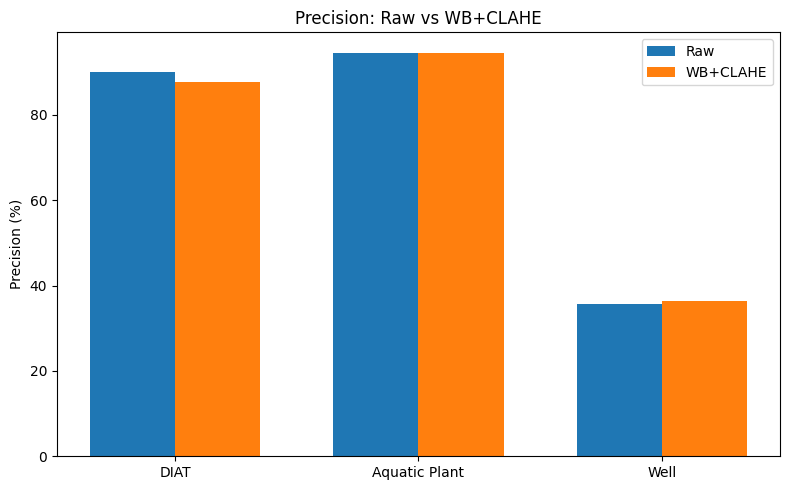

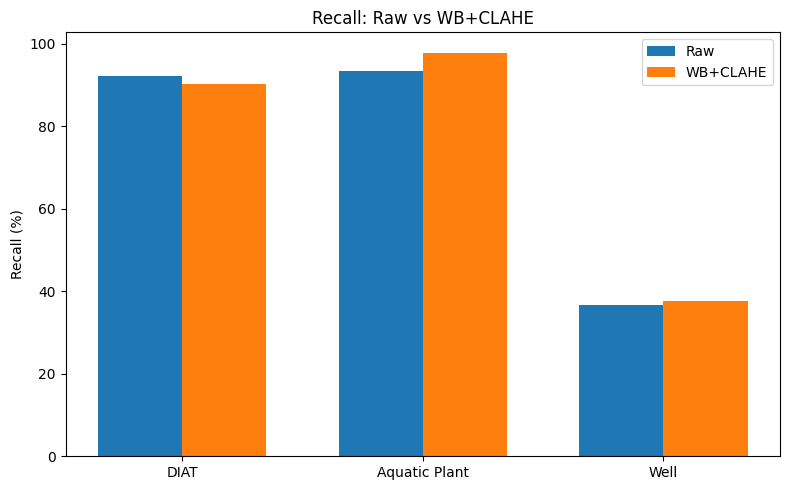

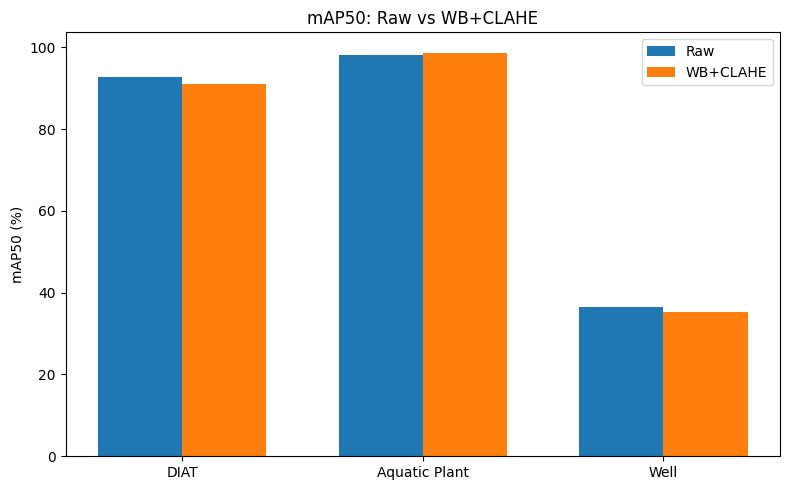

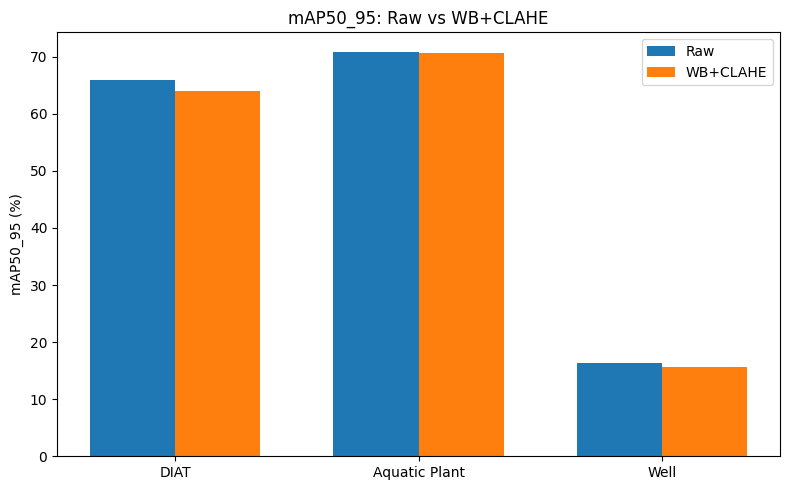

In [ ]:
metrics=["Precision","Recall","mAP50","mAP50_95"]
for metric in metrics:
    plt.figure(figsize=(8,5))
    x=np.arange(len(raw.index))
    width=0.35
    plt.bar(x-width/2,raw[metric],width,label="Raw")
    plt.bar(x+width/2,enhanced[metric],width,label="WB+CLAHE")
    plt.xticks(x,raw.index)
    plt.ylabel(metric+" (%)")
    plt.title(metric+": Raw vs WB+CLAHE")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
diat_classwise=[
["Aquatic Plant",97.98,98.78,98.57,79.12,97.32,99.02,98.47,78.96],
["Camera",96.87,93.33,93.50,57.16,96.64,86.67,95.23,55.77],
["Conch-Shell",90.35,94.34,93.73,70.90,91.56,95.57,94.53,70.05],
["Fish",83.84,84.08,88.38,49.06,83.06,81.94,86.77,46.77],
["Fishes",67.19,84.62,80.31,47.42,54.45,76.92,65.47,38.27],
["Pluco",89.36,88.89,90.79,68.93,88.99,89.78,91.90,68.27],
["Shark",92.87,96.23,96.61,65.69,92.45,95.82,97.11,65.14],
["Temperature Sensor",86.02,96.16,96.23,66.81,81.29,93.75,93.99,66.08],
["Water-Pump",92.11,87.42,93.20,72.80,90.73,88.08,94.00,72.93],
["Water-filter",98.87,90.48,91.85,73.76,92.58,85.71,88.89,67.62],
["betta",94.71,98.63,96.83,73.43,94.35,97.95,96.23,73.38]
]
cols=[
"Class",
"Raw_P","Raw_R","Raw_mAP50","Raw_mAP50_95",
"Enh_P","Enh_R","Enh_mAP50","Enh_mAP50_95"
]
diat_df=pd.DataFrame(diat_classwise,columns=cols)
diat_df["Delta_P"]=diat_df["Enh_P"]-diat_df["Raw_P"]
diat_df["Delta_R"]=diat_df["Enh_R"]-diat_df["Raw_R"]
diat_df["Delta_mAP50"]=diat_df["Enh_mAP50"]-diat_df["Raw_mAP50"]
diat_df["Delta_mAP50_95"]=diat_df["Enh_mAP50_95"]-diat_df["Raw_mAP50_95"]
diat_df=diat_df.sort_values("Delta_mAP50")
display(
    diat_df[
        ["Class","Raw_mAP50","Enh_mAP50","Delta_mAP50","Delta_mAP50_95"]
    ]
)
worst=diat_df.iloc[0]
print(
    f"Largest mAP@0.5 decrease: {worst['Class']} "
    f"({worst['Raw_mAP50']:.2f}% → {worst['Enh_mAP50']:.2f}%,"
    f"change={worst['Delta_mAP50']:.2f} percentage points)"
)

,Class,Raw_mAP50,Enh_mAP50,Delta_mAP50,Delta_mAP50_95
4,Fishes,80.31,65.47,-14.84,-9.15
9,Water-filter,91.85,88.89,-2.96,-6.14
7,Temperature Sensor,96.23,93.99,-2.24,-0.73
3,Fish,88.38,86.77,-1.61,-2.29
10,betta,96.83,96.23,-0.60,-0.05
0,Aquatic Plant,98.57,98.47,-0.10,-0.16
6,Shark,96.61,97.11,0.50,-0.55
2,Conch-Shell,93.73,94.53,0.80,-0.85
8,Water-Pump,93.20,94.00,0.80,0.13
5,Pluco,90.79,91.90,1.11,-0.66


Largest mAP@0.5 decrease: Fishes (80.31% → 65.47%,change=-14.84 percentage points)


In [ ]:
well_classwise=[
["fishes",67.10,73.10,71.30,27.20,70.70,67.00,69.20,26.00],
["school-of-fish",66.80,41.90,55.30,28.10,58.60,51.20,54.10,28.20],
["stone",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00]
]
well_df=pd.DataFrame(
    well_classwise,
    columns=[
        "Class",
        "Raw_P","Raw_R","Raw_mAP50","Raw_mAP50_95",
        "Enh_P","Enh_R","Enh_mAP50","Enh_mAP50_95"
    ]
)
well_df["Delta_P"]=well_df["Enh_P"]-well_df["Raw_P"]
well_df["Delta_R"]=well_df["Enh_R"]-well_df["Raw_R"]
well_df["Delta_mAP50"]=well_df["Enh_mAP50"]-well_df["Raw_mAP50"]
well_df["Delta_mAP50_95"]=well_df["Enh_mAP50_95"]-well_df["Raw_mAP50_95"]
display(well_df)
print("\nImportant observation:")
print("The stone class has 0% mAP in both raw and enhanced conditions.")
print("This indicates that enhancement did not change the result for this rare class.")
print("The Well dataset has very limited examples for some classes,which limits reliable class-level conclusions.")

,Class,Raw_P,Raw_R,Raw_mAP50,Raw_mAP50_95,Enh_P,Enh_R,Enh_mAP50,Enh_mAP50_95,Delta_P,Delta_R,Delta_mAP50,Delta_mAP50_95
0,fishes,67.1,73.1,71.3,27.2,70.7,67.0,69.2,26.0,3.6,-6.1,-2.1,-1.2
1,school-of-fish,66.8,41.9,55.3,28.1,58.6,51.2,54.1,28.2,-8.2,9.3,-1.2,0.1
2,stone,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Important observation:
The stone class has 0% mAP in both raw and enhanced conditions.
This indicates that enhancement did not change the result for this rare class.
The Well dataset has very limited examples for some classes,which limits reliable class-level conclusions.


In [ ]:
import os
base="/content/drive/MyDrive/Day16_YOLO_Baseline"
for root,dirs,files in os.walk(base):
    image_files=[
        f for f in files
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ]
    if image_files:
        print(root)
        print("Images:",len(image_files))
        print()

/content/drive/MyDrive/Day16_YOLO_Baseline/DIATAquarium
Images: 20

/content/drive/MyDrive/Day16_YOLO_Baseline/DIATAquarium/predictions/validation_predictions
Images: 10

/content/drive/MyDrive/Day16_YOLO_Baseline/Aquatic_Plant/predictions/validation_predictions
Images: 10

/content/drive/MyDrive/Day16_YOLO_Baseline/Well/predictions/visual_outputs/well_validation_predictions
Images: 10



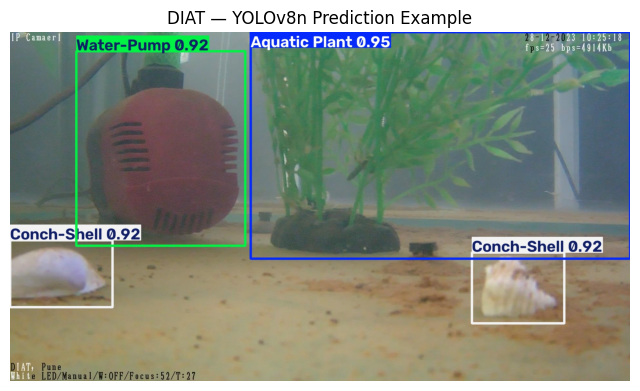

DIAT representative image: av0_0_20231228_102111_mp4-249_jpg.rf.a1519bb04f7e7d2c0d2d9c991cd5b465.jpg


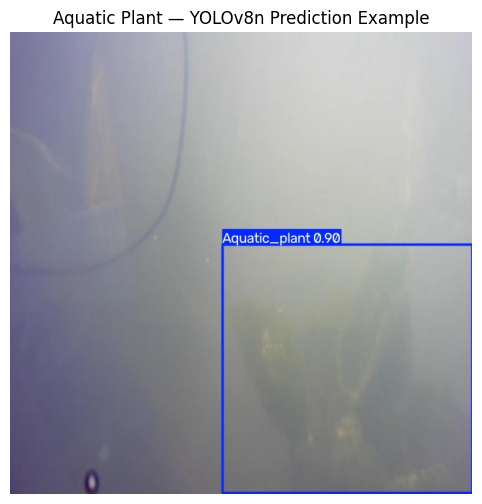

Aquatic Plant representative image: 2023-12-09_13_18_14_mp4-365_jpg.rf.ed76176e0e6bc147776b43d08af5563d.jpg


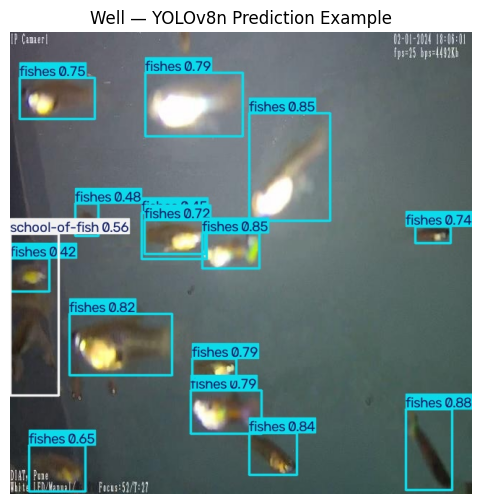

Well representative image: 20240102-20240102153559-20240102153818-153600_mp4-0018_jpg.rf.3049b746d34c60db5ad7211e9a49184c.jpg


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
prediction_folders={
    "DIAT":"/content/drive/MyDrive/Day16_YOLO_Baseline/DIATAquarium/predictions/validation_predictions",
    "Aquatic Plant":"/content/drive/MyDrive/Day16_YOLO_Baseline/Aquatic_Plant/predictions/validation_predictions",
    "Well":"/content/drive/MyDrive/Day16_YOLO_Baseline/Well/predictions/visual_outputs/well_validation_predictions"
}
for dataset,folder in prediction_folders.items():
    files=sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ])
    img_path=os.path.join(folder,files[0])
    img=Image.open(img_path)
    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.title(dataset+" — YOLOv8n Prediction Example")
    plt.axis("off")
    plt.show()
    print(dataset,"representative image:",files[0])

DIAT : 10 prediction images


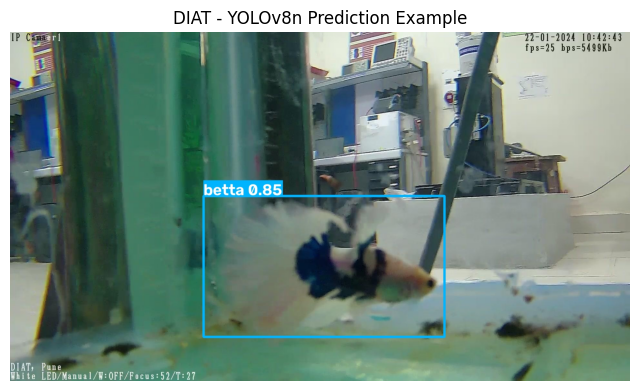

Aquatic Plant : 10 prediction images


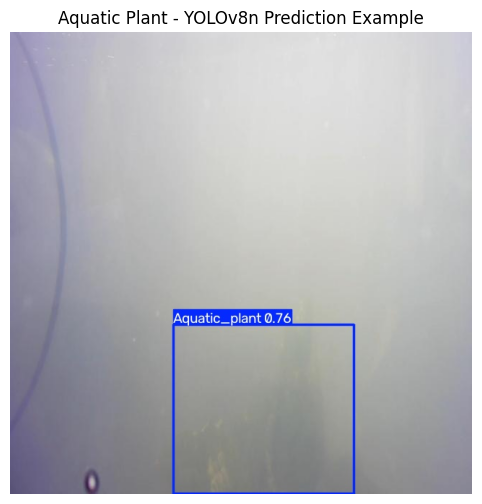

Well : 10 prediction images


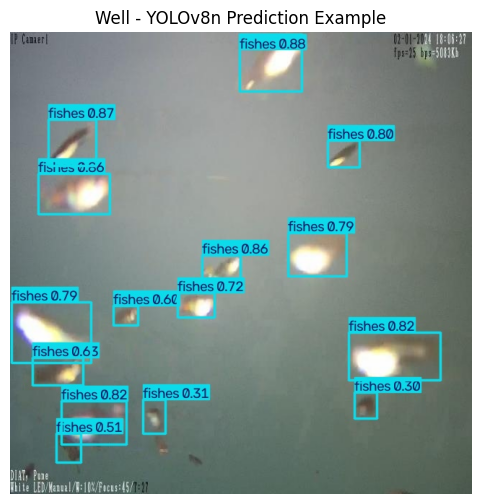

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
prediction_folders={
    "DIAT":"/content/drive/MyDrive/Day16_YOLO_Baseline/DIATAquarium/predictions/validation_predictions",
    "Aquatic Plant":"/content/drive/MyDrive/Day16_YOLO_Baseline/Aquatic_Plant/predictions/validation_predictions",
    "Well":"/content/drive/MyDrive/Day16_YOLO_Baseline/Well/predictions/visual_outputs/well_validation_predictions"
}
for dataset,folder in prediction_folders.items():
    files=[f for f in os.listdir(folder) if f.lower().endswith((".jpg",".jpeg",".png"))]
    print(dataset,":",len(files),"prediction images")

    if files:
        img_path=os.path.join(folder,files[0])
        img=Image.open(img_path)
        plt.figure(figsize=(8,6))
        plt.imshow(img)
        plt.title(dataset+" - YOLOv8n Prediction Example")
        plt.axis("off")
        plt.show()

In [ ]:
import os
base="/content/drive/MyDrive/Day17_YOLO_Enhanced"
for dataset in ["Aquatic_Plant","Well"]:
    dataset_path=os.path.join(base,dataset)
    print("\n",dataset)
    for root,dirs,files in os.walk(dataset_path):
        image_files=[
            f for f in files
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ]
        if image_files:
            print("Folder:",root)
            print("Images:",len(image_files))


 Aquatic_Plant
Folder: /content/drive/MyDrive/Day17_YOLO_Enhanced/Aquatic_Plant
Images: 20

 Well
Folder: /content/drive/MyDrive/Day17_YOLO_Enhanced/Well
Images: 20


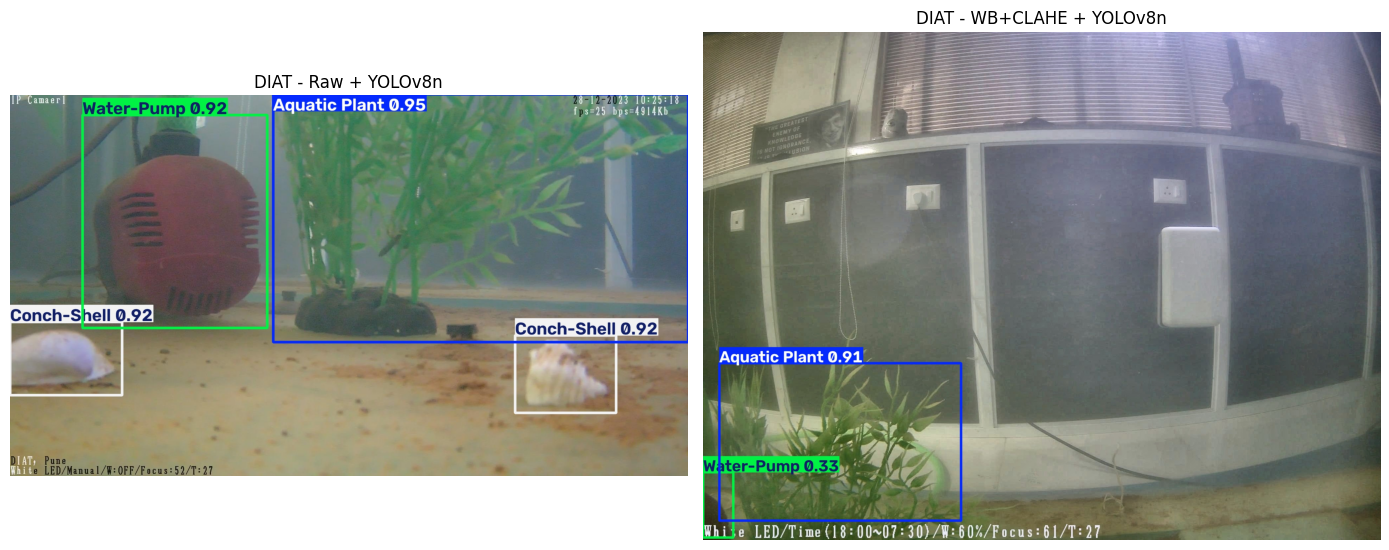

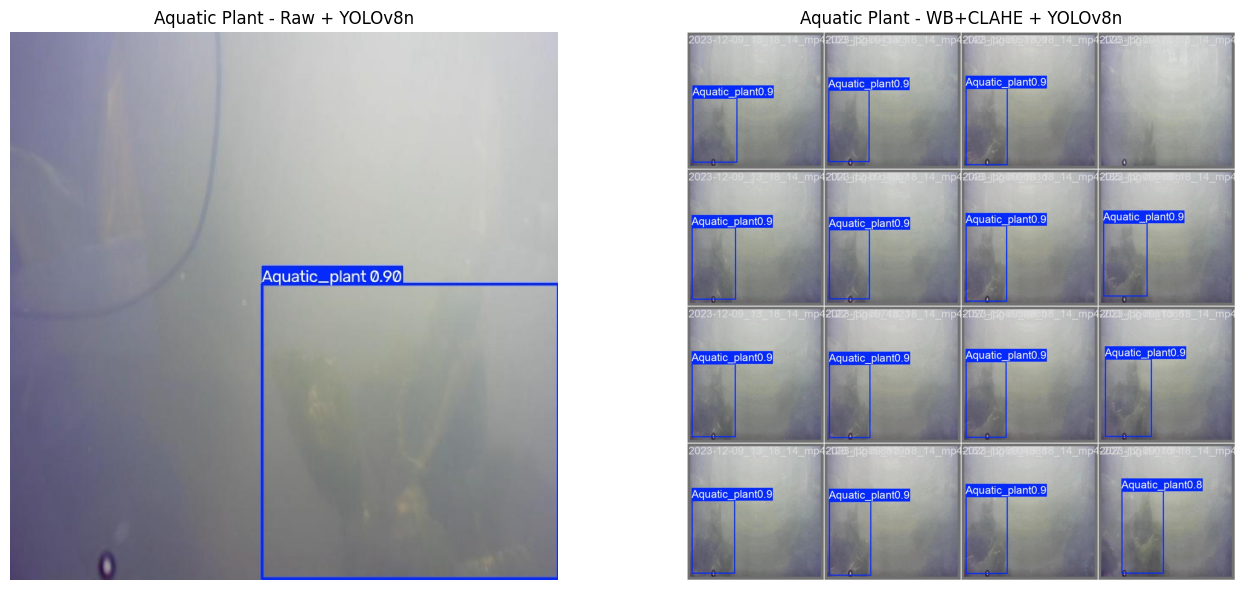

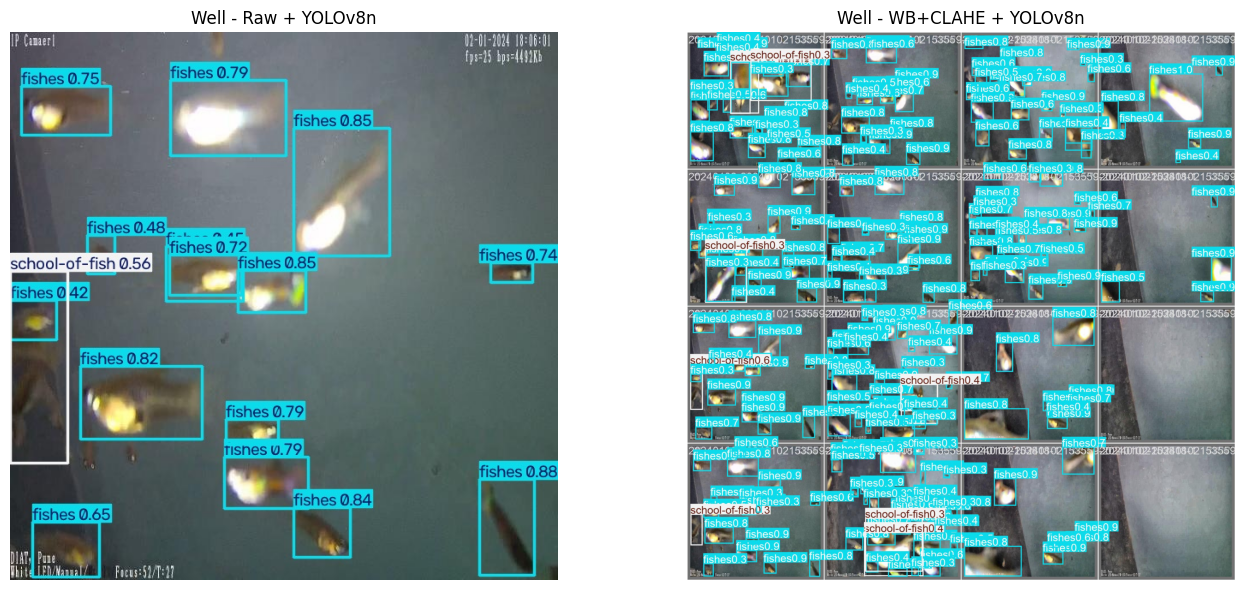

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
raw_folders={
    "DIAT":"/content/drive/MyDrive/Day16_YOLO_Baseline/DIATAquarium/predictions/validation_predictions",
    "Aquatic Plant":"/content/drive/MyDrive/Day16_YOLO_Baseline/Aquatic_Plant/predictions/validation_predictions",
    "Well":"/content/drive/MyDrive/Day16_YOLO_Baseline/Well/predictions/visual_outputs/well_validation_predictions"
}
enhanced_folders={
    "DIAT":"/content/drive/MyDrive/Day17_YOLO_Enhanced/DIATAquarium/predictions/validation_predictions",
    "Aquatic Plant":"/content/drive/MyDrive/Day17_YOLO_Enhanced/Aquatic_Plant",
    "Well":"/content/drive/MyDrive/Day17_YOLO_Enhanced/Well"
}
enhanced_files={
    "DIAT":"",
    "Aquatic Plant":"val_batch0_pred.jpg",
    "Well":"val_batch0_pred.jpg"
}
for dataset in raw_folders:
    r_folder=raw_folders[dataset]
    e_folder=enhanced_folders[dataset]
    r_files=sorted([
        f for f in os.listdir(r_folder)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ])
    if dataset=="DIAT":
        e_files=sorted([
            f for f in os.listdir(e_folder)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ])
        e_file=e_files[0]
    else:
        e_file=enhanced_files[dataset]
    r_img=Image.open(os.path.join(r_folder,r_files[0]))
    e_img=Image.open(os.path.join(e_folder,e_file))
    fig,axes=plt.subplots(1,2,figsize=(14,6))
    axes[0].imshow(r_img)
    axes[0].set_title(f"{dataset} - Raw + YOLOv8n")
    axes[0].axis("off")
    axes[1].imshow(e_img)
    axes[1].set_title(f"{dataset} - WB+CLAHE + YOLOv8n")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
summary="""# Day 20 - Robustness / Ablation Study

## Objective

This study evaluates the effect of White Balance + CLAHE enhancement on YOLOv8n object detection across the three supplied underwater datasets.

## Raw vs Enhanced Results

| Dataset | Condition | Precision (%) | Recall (%) | mAP@0.5 (%) | mAP@0.5:0.95 (%) | FPS |
|---|---|---:|---:|---:|---:|---:|
| DIAT | Raw + YOLOv8n | 90.02 | 92.09 | 92.72 | 65.90 | 47.05 |
| DIAT | WB+CLAHE + YOLOv8n | 87.70 | 90.20 | 91.10 | 64.00 | 33.38 |
| Aquatic Plant | Raw + YOLOv8n | 94.64 | 93.52 | 98.05 | 70.79 | 79.35 |
| Aquatic Plant | WB+CLAHE + YOLOv8n | 94.60 | 97.90 | 98.70 | 70.70 | 71.78 |
| Well | Raw + YOLOv8n | 35.60 | 36.80 | 36.50 | 16.40 | 53.91 |
| Well | WB+CLAHE + YOLOv8n | 36.30 | 37.70 | 35.20 | 15.70 | 63.23 |

## Main Findings

- DIAT performance decreased after WB+CLAHE.
- Aquatic Plant showed improvement mainly in Recall and mAP@0.5.
- Well showed mixed results,with Precision and Recall increasing while mAP decreased.
- Enhancement therefore has a dataset- and class-dependent effect.

## Class-Level Error Analysis

- DIAT Fishes showed the largest mAP@0.5 decrease: 80.31% → 65.47% (-14.84 percentage points).
- Well Stone remained at 0% mAP@0.5 in both conditions.
- Severe class imbalance in the Well dataset limits reliable rare-class conclusions.

## Research Insight

WB+CLAHE does not consistently improve YOLOv8n detection across all datasets. Image enhancement should therefore be experimentally validated rather than assumed to improve downstream object detection.

## Limitations

- White Balance and CLAHE were tested together,not separately.
- DIAT does not have a separate local test split.
- Dataset class distributions are different.
- The Well dataset contains severe class imbalance.
- Representative visual predictions were used for qualitative analysis.

## Conclusion

The robustness/ablation study shows that the effect of underwater image enhancement depends on the dataset and object classes. The numerical results and class-level analysis provide evidence for answering the project research question.
"""

path="/content/drive/MyDrive/Day20_Robustness_Ablation_Summary.md"

with open(path,"w") as f:
    f.write(summary)

print("Day 20 summary saved successfully.")
print(path)

Day 20 summary saved successfully.
/content/drive/MyDrive/Day20_Robustness_Ablation_Summary.md


## Research Question Interpretation

**Research Question:** How does underwater image enhancement affect YOLOv8n detection?

- **DIAT:** WB+CLAHE reduced all major detection metrics.
  - Precision: 90.02% → 87.70% (-2.32pp)
  - Recall: 92.09% → 90.20% (-1.89pp)
  - mAP@0.5: 92.72% → 91.10% (-1.62pp)
  - mAP@0.5:0.95: 65.90% → 64.00% (-1.90pp)
  - This indicates that enhancement did not improve detection for DIAT.

- **Aquatic Plant:** WB+CLAHE improved detection in selected metrics.
  - Recall: 93.52% → 97.90% (+4.38pp)
  - mAP@0.5: 98.05% → 98.70% (+0.65pp)
  - mAP@0.5:0.95: 70.79% → 70.70% (-0.09pp)
  - The improvement is mainly visible in Recall and mAP@0.5.

- **Well:** Results were mixed.
  - Precision: 35.60% → 36.30% (+0.70pp)
  - Recall: 36.80% → 37.70% (+0.90pp)
  - mAP@0.5: 36.50% → 35.20% (-1.30pp)
  - mAP@0.5:0.95: 16.40% → 15.70% (-0.70pp)
  - This shows that higher Precision and Recall did not translate into better overall mAP.

**Overall finding:** WB+CLAHE has a dataset- and class-dependent effect. It improves some detection measures for Aquatic Plant,but does not consistently improve detection across all three datasets.

## Remaining Weaknesses

- **DIAT class confusion:** The Fishes class had the largest degradation.
  - mAP@0.5: 80.31% → 65.47% (-14.84pp)
  - This suggests that enhancement can affect class-level discrimination.

- **Well class imbalance:** The stone class remained at 0% in both conditions.
  - mAP@0.5: 0% → 0%
  - Very limited examples make this class difficult to learn reliably.

- **Well overall performance:** mAP@0.5 decreased from 36.50% to 35.20%.
  - This shows that small Precision/Recall improvements did not improve overall localization performance.

- **DIAT dataset:** Fish and Fishes are visually similar classes,which can make discrimination difficult.

- **Enhancement limitation:** WB and CLAHE were evaluated together. Their individual contributions were not isolated.

- **Data limitation:** The current DIAT project copy does not contain a separate local test split.

**Main weakness:** Image enhancement can improve visual characteristics without necessarily improving downstream object detection.

## Final Research Insight

- WB+CLAHE does not consistently improve detection.
- Its effect differs across datasets and classes.
- Aquatic Plant showed improvement in selected metrics.
- DIAT showed an overall performance decrease.
- Well showed mixed results.
- Enhancement should be validated rather than assumed to improve detection.